<a href="https://colab.research.google.com/github/vaishnaviiisharma2005-ai/workshop_project/blob/main/retailed_workshop_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
"""
Online Retail Customer Segmentation
Using RFM Analysis + Clustering
"""

import imblearn
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

from sklearn.cluster import KMeans
from sklearn.cluster import AgglomerativeClustering
from sklearn.cluster import DBSCAN

from sklearn.metrics import silhouette_score




In [6]:
# DATA LOADING


df = pd.read_excel("retail_dataset.xlsx")

print(df.head())
print(df.info())

# DATA CLEANING
# remove rows with missing customer id
df = df.dropna(subset=["Customer ID"])

# remove canceled orders
df = df[~df["Invoice"].astype(str).str.contains("C")]

# create total price
df["TotalPrice"] = df["Quantity"] * df["Price"]
print(df.head())




  Invoice StockCode                          Description  Quantity  \
0  489434     85048  15CM CHRISTMAS GLASS BALL 20 LIGHTS        12   
1  489434    79323P                   PINK CHERRY LIGHTS        12   
2  489434    79323W                  WHITE CHERRY LIGHTS        12   
3  489434     22041         RECORD FRAME 7" SINGLE SIZE         48   
4  489434     21232       STRAWBERRY CERAMIC TRINKET BOX        24   

          InvoiceDate  Price  Customer ID         Country  
0 2009-12-01 07:45:00   6.95      13085.0  United Kingdom  
1 2009-12-01 07:45:00   6.75      13085.0  United Kingdom  
2 2009-12-01 07:45:00   6.75      13085.0  United Kingdom  
3 2009-12-01 07:45:00   2.10      13085.0  United Kingdom  
4 2009-12-01 07:45:00   1.25      13085.0  United Kingdom  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 525461 entries, 0 to 525460
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   Invo

In [7]:
# RFM FEATURE ENGINEERING
snapshot_date = df["InvoiceDate"].max() + pd.Timedelta(days=1)

rfm = df.groupby("Customer ID").agg({

"InvoiceDate": lambda x: (snapshot_date - x.max()).days,
"Invoice": "nunique",
"TotalPrice": "sum"

})

rfm.rename(columns={

"InvoiceDate": "Recency",
"Invoice": "Frequency",
"TotalPrice": "Monetary"

}, inplace=True)

print(rfm.head())



             Recency  Frequency  Monetary
Customer ID                              
12346.0          165         11    372.86
12347.0            3          2   1323.32
12348.0           74          1    222.16
12349.0           43          3   2671.14
12351.0           11          1    300.93


In [8]:

# SCALING
#Log Transformation
rfm["Recency"] = np.log1p(rfm["Recency"])
rfm["Frequency"] = np.log1p(rfm["Frequency"])
rfm["Monetary"] = np.log1p(rfm["Monetary"])

# Removing Outliers
Q1 = rfm.quantile(0.25)
Q3 = rfm.quantile(0.75)

IQR = Q3 - Q1

rfm = rfm[~((rfm < (Q1 - 1.5 * IQR)) |
            (rfm > (Q3 + 1.5 * IQR))).any(axis=1)]
scaler = StandardScaler()

rfm_scaled = scaler.fit_transform(rfm)

rfm_scaled = pd.DataFrame(rfm_scaled, columns=rfm.columns)

print(rfm_scaled.head())



    Recency  Frequency  Monetary
0  0.963194   1.819001 -0.551261
1 -1.942774  -0.383536  0.513407
2  0.343500  -1.027736 -0.985617
3 -0.072463   0.073532  1.104325
4 -1.085878  -1.027736 -0.731139


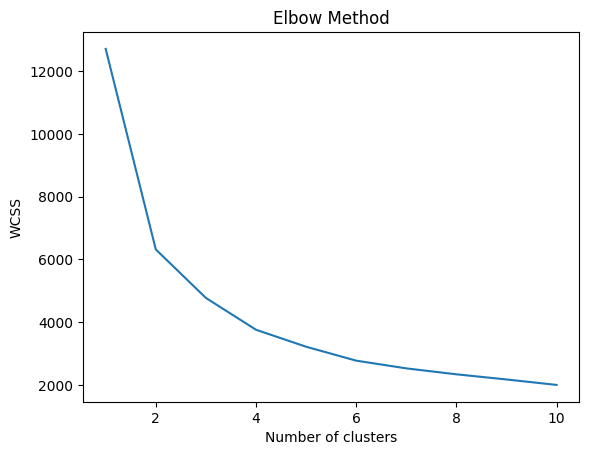

KMeans Silhouette Score: 0.33634161800443674
Hierarchical Silhouette Score: 0.26189065899473873
DBSCAN Silhouette Score: 0.29454226314636955


In [9]:

# KMEANS CLUSTERING
wcss = []

for i in range(1,11):

    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(rfm_scaled)

    wcss.append(kmeans.inertia_)

plt.plot(range(1,11), wcss)
plt.title("Elbow Method")
plt.xlabel("Number of clusters")
plt.ylabel("WCSS")
plt.show()


kmeans = KMeans(n_clusters=4, random_state=42)

rfm["Cluster_KMeans"] = kmeans.fit_predict(rfm_scaled)

print("KMeans Silhouette Score:",
      silhouette_score(rfm_scaled, rfm["Cluster_KMeans"]))


# HIERARCHICAL CLUSTERING
hier = AgglomerativeClustering(n_clusters=4)

rfm["Cluster_Hier"] = hier.fit_predict(rfm_scaled)

print("Hierarchical Silhouette Score:",
      silhouette_score(rfm_scaled, rfm["Cluster_Hier"]))


# DBSCAN CLUSTERING
db = DBSCAN(eps=0.7, min_samples=5)

rfm["Cluster_DBSCAN"] = db.fit_predict(rfm_scaled)

print("DBSCAN Silhouette Score:",
      silhouette_score(rfm_scaled, rfm["Cluster_DBSCAN"]))



Explained Variance: [0.73137117 0.20540822]


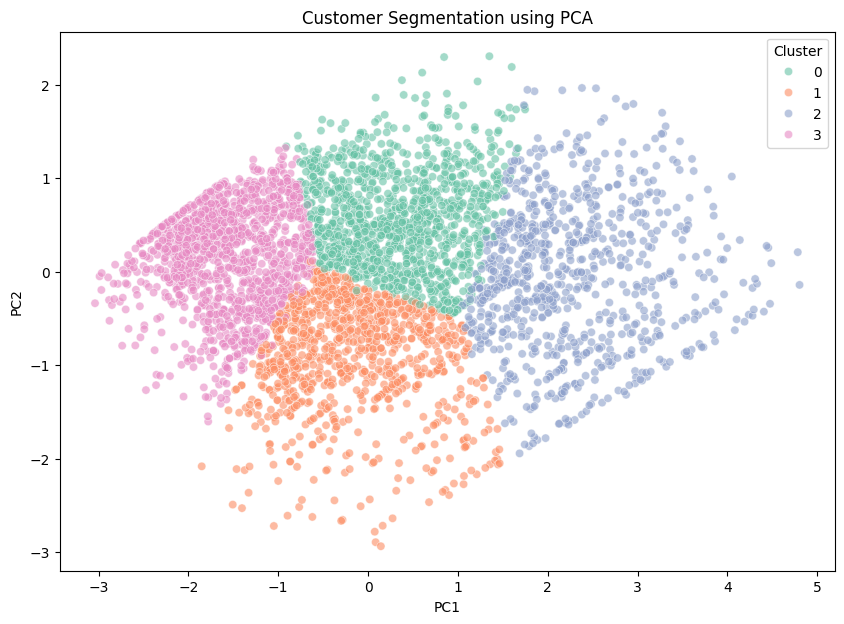

In [10]:

# PCA VISUALIZATION
pca = PCA(n_components=2)

rfm_pca = pca.fit_transform(rfm_scaled)

pca_df = pd.DataFrame(rfm_pca, columns=["PC1","PC2"])

pca_df["Cluster"] = rfm["Cluster_KMeans"].values

print("Explained Variance:", pca.explained_variance_ratio_)


# CLUSTER VISUALIZATION
plt.figure(figsize=(10,7))
sns.scatterplot(
    x="PC1",
    y="PC2",
    hue="Cluster",
    data=pca_df,
    palette="Set2",
    alpha=0.6
)

plt.title("Customer Segmentation using PCA")
plt.show()


In [11]:

# CLUSTER ANALYSIS
cluster_summary = rfm.groupby("Cluster_KMeans").mean()
print(cluster_summary)

# NEW CUSTOMER CLUSTER PREDICTION
print("\nEnter new customer details")

recency = float(input("Recency (days since last purchase): "))
frequency = float(input("Frequency (number of purchases): "))
monetary = float(input("Monetary (total money spent): "))

# Apply same log transformation used during training
user_data = pd.DataFrame({
    "Recency":[np.log1p(recency)],
    "Frequency":[np.log1p(frequency)],
    "Monetary":[np.log1p(monetary)]
})

# Apply the same scaler
user_scaled = scaler.transform(user_data)

# Predict cluster
cluster = kmeans.predict(user_scaled)

print("\nCustomer belongs to Cluster:", cluster[0])

                 Recency  Frequency  Monetary  Cluster_Hier  Cluster_DBSCAN
Cluster_KMeans                                                             
0               4.270833   1.528793  7.192733      1.989529       -0.003490
1               2.957768   1.042182  6.106546      1.037118       -0.003275
2               2.415115   2.293620  8.050856      0.002407        0.000000
3               5.070093   0.793225  5.468501      2.000000        0.000000

Enter new customer details
Recency (days since last purchase): 25
Frequency (number of purchases): 2
Monetary (total money spent): 2500

Customer belongs to Cluster: 0


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but KMeans was fitted with feature names
  warnings.warn(
